
# Monte Carlo pour le pricing d'options européennes

**Objectifs**
- Implémenter un moteur Monte Carlo (MC) pour **calls/puts européens** sous GBM.
- Valider vs **Black–Scholes** (référence fermée).
- Mesurer **erreur-type** et **IC 95%**, tracer la **convergence**.
- Appliquer **réductions de variance** (antithétiques, control variate).
- Calculer des **Greeks** (delta pathwise, vega likelihood-ratio).



## 0) Imports, seed & paramètres


In [37]:
import numpy as np
import math
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

S0, K, T = 100.0, 100.0, 1.0
r, sigma = 0.02, 0.20

print("Params:", S0, K, T, r, sigma)

Params: 100.0 100.0 1.0 0.02 0.2



## 1) Black–Scholes
On utilise BS pour valider nos estimateurs MC.


In [38]:
def _phi(x):  # pdf gaussian
    return (1.0 / math.sqrt(2.0*math.pi)) * math.exp(-0.5*x**2)
def _Phi(x):  # cdf gaussian
    return 0.5*(1.0 + math.erf(x / math.sqrt(2.0)))

In [39]:
def bs_call_price(S0, K, T, r, sigma):
    if T <= 0.0: return max(S0-K, 0.0)
    d1 = (math.log(S0/K) + (r+0.5*sigma*sigma)*T) / (sigma*math.sqrt(T))
    d2 = d1 - sigma*math.sqrt(T)
    return S0*_Phi(d1) - K*math.exp(-r*T)*_Phi(d2)

def bs_put_price(S0, K, T, r, sigma):
    if T <= 0.0: return max(K-S0, 0.0)
    d1 = (math.log(S0/K) + (r+0.5*sigma*sigma)*T) / (sigma*math.sqrt(T))
    d2 = d1 - sigma*math.sqrt(T)
    return K*math.exp(-r*T)*_Phi(-d2) - S0*_Phi(-d1)

In [40]:
def bs_call_delta(S0, K, T, r, sigma):
    if T <= 0.0: return (1.0 if S0>K else (0.0 if S0<K else 0.5))
    d1 = (math.log(S0/K) + (r+0.5*sigma*sigma)*T) / (sigma*math.sqrt(T))
    return _Phi(d1)

def bs_call_vega(S0, K, T, r, sigma):
    if T <= 0.0 or sigma <= 0.0: return 0.0
    d1 = (math.log(S0/K) + (r+0.5*sigma*sigma)*T) / (sigma*math.sqrt(T))
    return S0*_phi(d1)*math.sqrt(T)

In [41]:
bs_ref = bs_call_price(S0, K, T, r, sigma)
print("Black–Scholes call =", bs_ref)

Black–Scholes call = 8.916037278572539



## 2) Monte Carlo basique (one-step, terminal lognormal)
Under risk-neutral probability measure :  
$$ S_T = S_0 \exp\{(r-\tfrac12\sigma^2)T + \sigma\sqrt{T}\,Z\},\; Z\sim\mathcal N(0,1)$$


In [42]:
def simulate_ST(S0, r, sigma, T, n, antithetic=False):
    if not antithetic:
        Z = rng.standard_normal(n)
    else:
        m = n // 2
        Z = rng.standard_normal(m)
        Z = np.concatenate([Z, -Z])
    return S0 * np.exp((r-0.5*sigma**2)*T + sigma*math.sqrt(T)*Z)

def mc_european_call(S0, K, T, r, sigma, n=100000, antithetic=False):
    ST = simulate_ST(S0, r, sigma, T, n, antithetic)
    payoff = np.maximum(ST - K, 0.0)
    disc = math.exp(-r*T)
    price = disc*payoff.mean()
    stderr = disc*payoff.std(ddof=1)/math.sqrt(len(payoff))
    return price, stderr

p, se = mc_european_call(S0, K, T, r, sigma, 100000)
print(f"MC simple: {p:.4f} ± {1.96*se:.4f} (IC95%)  vs  BS {bs_ref:.4f}")

MC simple: 8.8935 ± 0.0860 (IC95%)  vs  BS 8.9160



## 3) Convergence & intervalles de confiance
Erreur-type $\propto 1/\sqrt{N}$. On montre la décroissance quand $N$ augmente.


In [43]:
def convergence_curve(S0, K, T, r, sigma, Ns, antithetic=False):
    est, se = [], []
    for N in Ns:
        p, s = mc_european_call(S0, K, T, r, sigma, N, antithetic)
        est.append(p); se.append(s)
    return np.array(est), np.array(se)

Ns = np.unique((np.logspace(3, 5, 10)).astype(int))
est, se = convergence_curve(S0, K, T, r, sigma, Ns)

for N, p, s in zip(Ns, est, se):
    print(f"N={N:6d}  prix={p:7.4f}  IC95%±={1.96*s:6.4f}")

N=  1000  prix= 8.7664  IC95%±=0.9011
N=  1668  prix= 8.7456  IC95%±=0.6631
N=  2782  prix= 8.9358  IC95%±=0.5182
N=  4641  prix= 8.9365  IC95%±=0.4070
N=  7742  prix= 9.0179  IC95%±=0.3133
N= 12915  prix= 8.9137  IC95%±=0.2383
N= 21544  prix= 8.9656  IC95%±=0.1853
N= 35938  prix= 9.0612  IC95%±=0.1445
N= 59948  prix= 8.8744  IC95%±=0.1099
N=100000  prix= 8.9067  IC95%±=0.0854


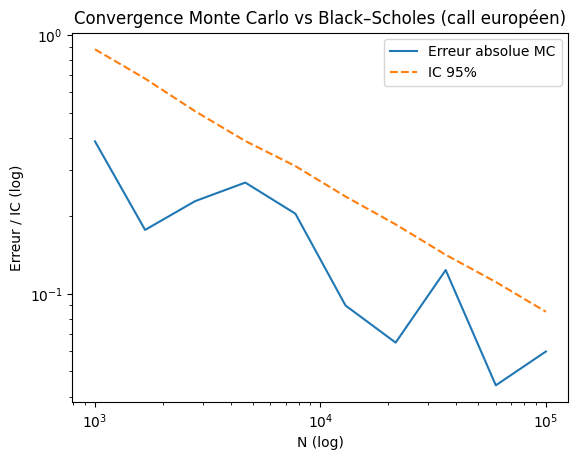

In [44]:
bs_ref = bs_call_price(S0, K, T, r, sigma)

plt.figure()

Ns = np.unique((np.logspace(3, 5, 10)).astype(int))
est, se = convergence_curve(S0, K, T, r, sigma, Ns)
plt.plot(Ns, np.abs(est - bs_ref), label="Erreur absolue MC")
plt.plot(Ns, 1.96*se, label="IC 95%", linestyle="--")
plt.xscale("log"); plt.yscale("log")
plt.xlabel("N (log)"); plt.ylabel("Erreur / IC (log)")
plt.title("Convergence Monte Carlo vs Black–Scholes (call européen)")
plt.legend()
plt.show()


## 4) Antithétiques


In [ ]:
p0, s0 = mc_european_call(S0, K, T, r, sigma, 10000, antithetic=False)
p1, s1 = mc_european_call(S0, K, T, r, sigma, 10000, antithetic=True)
print(f"SE simple: {s0:.6f}   SE antithétique: {s1:.6f}")

SE simple: 0.137229   SE antithétique: 0.136402



## 5) Greeks par Monte Carlo
**Delta (pathwise)** et **Vega (likelihood-ratio)**.


In [45]:
def mc_delta_pathwise(S0, K, T, r, sigma, n=200_000):
    Z  = rng.standard_normal(n)
    ST = S0 * np.exp((r - 0.5 * sigma ** 2) * T + sigma * math.sqrt(T) * Z)
    ind = (ST > K).astype(float)
    dST_dS0 = ST / S0
    disc = math.exp(-r * T)
    g = disc * ind * dST_dS0
    return g.mean(), g.std(ddof=1)/math.sqrt(n)

def mc_vega_likelihood_ratio(S0, K, T, r, sigma, n=200_000):
    Z  = rng.standard_normal(n)
    ST = S0 * np.exp((r - 0.5 * sigma * sigma) * T + sigma * math.sqrt(T) * Z)
    payoff = np.maximum(ST - K, 0.0)
    disc = math.exp(-r * T)
    weight = (Z**2 - 1.0) / sigma - math.sqrt(T) * Z
    g = disc * payoff * weight
    return g.mean(), g.std(ddof=1)/math.sqrt(n)

delta_pw, se_delta = mc_delta_pathwise(S0, K, T, r, sigma)
vega_lr,  se_vega  = mc_vega_likelihood_ratio(S0, K, T, r, sigma)

print(f"Delta MC (pathwise) = {delta_pw:.4f} ± {1.96*se_delta:.4f}")
print(f"Vega  MC (LR)       = {vega_lr:.4f} ± {1.96*se_vega:.4f}")

Delta MC (pathwise) = 0.5801 ± 0.0026
Vega  MC (LR)       = 39.2832 ± 1.1480
